<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorium 7
## Użycie metod Monte Carlo w metrologii

---

### Piotr Kitlowski
#### indeks: 303865

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_student_t(mu, sigma, nu, size):
    """
    Generuje zmienną o rozkładzie t-Studenta przesuniętym i skalowanym:
    xi = mu + t_nu * sigma / sqrt(nu + 1) -> zgodnie z treścią zadania (uwaga 1)
    Uwaga: Standardowo w JCGM t_nu skaluje się bezpośrednio przez sigma,
    ale implementujemy jawnie wzór podany w instrukcji: xi = mu + t * sigma / sqrt(nu + 1).
    """
    t_dist = np.random.standard_t(df=nu, size=size)
    return mu + (t_dist * sigma) / np.sqrt(nu + 1)

def generate_arc_sine(a, b, size):
    """
    Generuje zmienną o rozkładzie arcus sinus (U-składny) przy użyciu transformacji:
    xi = (a + b)/2 + (b - a)/2 * sin(2 * pi * r)
    """
    r = np.random.random(size=size)
    return (a + b) / 2.0 + ((b - a) / 2.0) * np.sin(2 * np.pi * r)

def generate_trapezoidal(a, b, d, size):
    """
    Generuje zmienną o rozkładzie trapezowym Ctrap(a, b, d) metodą dekompozycji.
    Wzór podany w instrukcji: xi = a + (b - a)/2 * ((1 + d)*r1 + (1 - d)*r2)
    gdzie r1, r2 ~ R(0, 1)
    """
    r1 = np.random.random(size=size)
    r2 = np.random.random(size=size)
    return a + ((b - a) / 2.0) * ((1 + d) * r1 + (1 - d) * r2)

Uruchamianie symulacji Monte Carlo dla N = 1,000,000 powtórzeń...

## WYNIKI ANALIZY MONTE CARLO (w nanometrach - nm) ##
Estymator błędu pomiaru (Średnia Y): 838.00 nm
Odchylenie standardowe (Niepewność u(Y)): 16.23 nm
Przedział rozszerzenia dla p=0.99: [795.68 nm , 879.78 nm]
Szerokość przedziału rozszerzenia: 84.10 nm


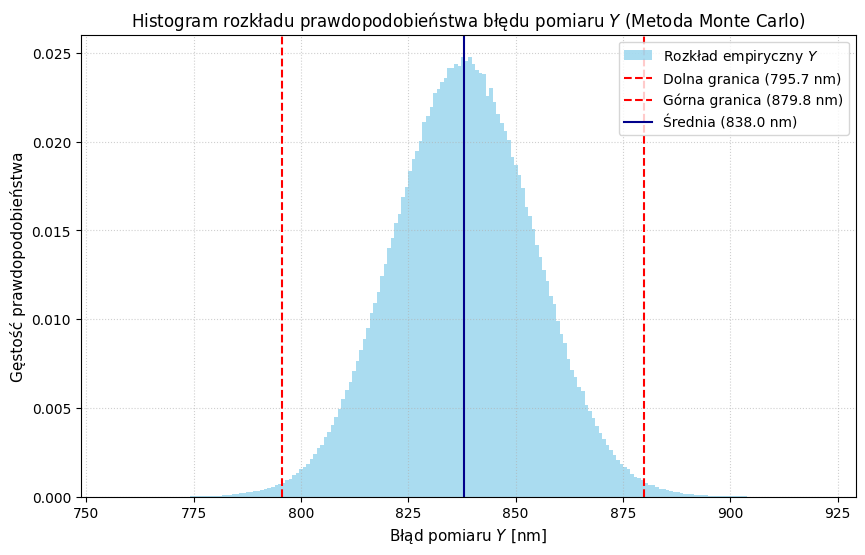

In [3]:
# -----------------------------------------------------------------------------
# Parametry symulacji
# -----------------------------------------------------------------------------
N = 1_000_000  # Liczba prób Monte Carlo (zalecana dla p=0.99)
K = 50_000_000  # Nominalna grubość płytki K = 50 mm skonwertowana na nanometry (nm)

print(f"Uruchamianie symulacji Monte Carlo dla N = {N:,} powtórzeń...\n")

# -----------------------------------------------------------------------------
# Generowanie prób losowych dla zmiennych wejściowych (wszystkie jednostki w nm lub °C)
# -----------------------------------------------------------------------------
# X1 do X4: Rozkłady t-Studenta (w nm)
X1 = generate_student_t(mu=50000623, sigma=25, nu=18, size=N)
X2 = generate_student_t(mu=215, sigma=6, nu=24, size=N)
X3 = generate_student_t(mu=0, sigma=4, nu=5, size=N)
X4 = generate_student_t(mu=0, sigma=7, nu=8, size=N)

# X5: Rozkład jednostajny R(a, b) (w °C^-1)
X5 = np.random.uniform(low=9.5e-6, high=1.35e-5, size=N)

# X6: Rozkład normalny N(mu, sigma^2) (w °C)
X6 = np.random.normal(loc=-0.1, scale=0.2, size=N)

# X7: Rozkład arcus sinus U(a, b) (w °C)
X7 = generate_arc_sine(a=-0.5, b=0.5, size=N)

# X8: Rozkład trapezowy Ctrap(a, b, d) (w °C^-1)
# Uwaga: w tabeli d=1e-7, co stanowi parametr d (stosunek bazy górnej do dolnej mieści się w [0,1])
X8 = generate_trapezoidal(a=-1e-6, b=1e-6, d=1e-7, size=N)

# X9: Rozkład trapezowy Ctrap(a, b, d) (w °C)
X9 = generate_trapezoidal(a=-0.05, b=0.05, d=0.025, size=N)

# -----------------------------------------------------------------------------
# Obliczenie zmiennej wyjściowej Y
# -----------------------------------------------------------------------------
# Wzór: Y = X1 + X2 + X3 + X4 - X1 * [ X8 * (X6 + X7) + X5 * X9 ] - K
Y = X1 + X2 + X3 + X4 - X1 * (X8 * (X6 + X7) + X5 * X9) - K

# -----------------------------------------------------------------------------
# Wyznaczenie statystyk i przedziału rozszerzenia (p = 0.99)
# -----------------------------------------------------------------------------
# Estymator (wartość oczekiwana) i odchylenie standardowe (niepewność standardowa)
mean_Y = np.mean(Y)
std_Y = np.std(Y, ddof=1)

# Wyznaczanie najkrótszego przedziału pokrycia dla p = 0.99 zgodnie z JCGM 101 (Shortest Coverage Interval)
p = 0.99
Y_sorted = np.sort(Y)
q = int(np.floor(p * N))  # Liczba punktów wewnątrz przedziału

# Szukamy takiego indeksu i, dla którego Y[i + q] - Y[i] jest najmniejsze
idx_start = 0
min_width = Y_sorted[q] - Y_sorted[0]

for i in range(1, N - q):
    width = Y_sorted[i + q] - Y_sorted[i]
    if width < min_width:
        min_width = width
        idx_start = i

y_low = Y_sorted[idx_start]
y_high = Y_sorted[idx_start + q]

# -----------------------------------------------------------------------------
# Prezentacja wyników
# -----------------------------------------------------------------------------
print("## WYNIKI ANALIZY MONTE CARLO (w nanometrach - nm) ##")
print(f"Estymator błędu pomiaru (Średnia Y): {mean_Y:.2f} nm")
print(f"Odchylenie standardowe (Niepewność u(Y)): {std_Y:.2f} nm")
print(f"Przedział rozszerzenia dla p=0.99: [{y_low:.2f} nm , {y_high:.2f} nm]")
print(f"Szerokość przedziału rozszerzenia: {y_high - y_low:.2f} nm")

# -----------------------------------------------------------------------------
# Wizualizacja histogramu gęstości prawdopodobieństwa Y
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(Y, bins=200, density=True, color='skyblue', alpha=0.7, label='Rozkład empiryczny $Y$')

# Zaznaczenie przedziału rozszerzenia
plt.axvline(y_low, color='red', linestyle='--', linewidth=1.5, label=f'Dolna granica ({y_low:.1f} nm)')
plt.axvline(y_high, color='red', linestyle='--', linewidth=1.5, label=f'Górna granica ({y_high:.1f} nm)')

# Estymator średniej
plt.axvline(mean_Y, color='darkblue', linestyle='-', linewidth=1.5, label=f'Średnia ({mean_Y:.1f} nm)')

plt.title('Histogram rozkładu prawdopodobieństwa błędu pomiaru $Y$ (Metoda Monte Carlo)', fontsize=12)
plt.xlabel('Błąd pomiaru $Y$ [nm]', fontsize=11)
plt.ylabel('Gęstość prawdopodobieństwa', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()